🔹 CELL 1 — Imports + Mount Drive

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Mount Google Drive (only needed once per session)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


🔹 CELL 2 — Load ERCOT Native Load Data

In [20]:
# Folder where ERCOT CSVs are stored
load_path = "/content/drive/MyDrive/Colab_Notebooks_Files/"

load_files = [
    "Native_Load_2022.csv",
    "Native_Load_2023.csv",
    "Native_Load_2024.csv"
]

df_list = []

for file in load_files:
    temp = pd.read_csv(load_path + file)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("Raw combined shape:", df.shape)

Raw combined shape: (26304, 10)


🔹 CELL 3 — Clean ERCOT Load Data

In [21]:
# Convert Hour Ending to datetime
df['datetime'] = pd.to_datetime(df['Hour Ending'], errors='coerce')

# Remove commas from ERCOT column and convert to float
df['load_mw'] = df['ERCOT'].str.replace(',', '', regex=False).astype(float)

# Keep only needed columns
df = df[['datetime', 'load_mw']]

# Sort (DO NOT drop duplicates)
df = df.sort_values('datetime').reset_index(drop=True)

print("Cleaned shape:", df.shape)
print(df.head())

Cleaned shape: (26304, 2)
             datetime   load_mw
0 2022-01-01 01:00:00  38006.94
1 2022-01-01 02:00:00  37036.52
2 2022-01-01 03:00:00  35881.61
3 2022-01-01 04:00:00  35044.06
4 2022-01-01 05:00:00  34585.57


In [22]:
print(df.shape)

(26304, 2)


🔹 CELL 4 — Load Houston Weather Data

In [25]:
weather_path = "/content/drive/MyDrive/Colab_Notebooks_Files/"

weather_files = [
    "houston_weather_data_2022.csv",
    "houston_weather_data_2023.csv",
    "houston_weather_data_2024.csv"
]

weather_list = []

for file in weather_files:
    temp = pd.read_csv(weather_path + file, low_memory=False)
    weather_list.append(temp)

weather_df = pd.concat(weather_list, ignore_index=True)

print(weather_df.shape)

(37214, 103)


🔹 CELL 5 — Clean Weather Data

In [26]:
# Convert DATE to datetime (floor to hour)
weather_df['datetime'] = pd.to_datetime(weather_df['DATE']).dt.floor('h')

# Extract numeric temperature (tenths of °C)
weather_df['TMP'] = (
    weather_df['TMP']
    .str.replace('+','', regex=False)
    .str.split(',')
    .str[0]
)

weather_df['TMP'] = pd.to_numeric(weather_df['TMP'], errors='coerce')

weather_df = weather_df[['datetime','TMP']]
weather_df = weather_df.dropna()

# Average multiple reports per hour
weather_hourly = weather_df.groupby('datetime', as_index=False)['TMP'].mean()

print(weather_hourly.head())

             datetime    TMP
0 2022-01-01 00:00:00  247.0
1 2022-01-01 01:00:00  244.0
2 2022-01-01 02:00:00  244.0
3 2022-01-01 03:00:00  244.0
4 2022-01-01 04:00:00  244.0


🔹 CELL 6 — Merge Load + Weather

In [27]:
merged_df = pd.merge(df, weather_hourly, on='datetime', how='left')

print("Missing temperature values:", merged_df['TMP'].isna().sum())

Missing temperature values: 1099


🔹 CELL 7 — Convert Temperature to °C

In [32]:
merged_df['TMP_C'] = merged_df['TMP'] / 10

In [36]:
print(merged_df[['TMP','TMP_C']].head())

           TMP       TMP_C
0   244.000000   24.400000
1   244.000000   24.400000
2   244.000000   24.400000
3   244.000000   24.400000
4  6745.666667  674.566667


In [37]:
# Remove unrealistic temperature values from corrupted NOAA records
merged_df = merged_df[(merged_df['TMP_C'] > -30) & (merged_df['TMP_C'] < 50)]

print("Rows remaining after cleaning:", merged_df.shape)
print("Max temperature:", merged_df['TMP_C'].max())
print("Min temperature:", merged_df['TMP_C'].min())

Rows remaining after cleaning: (24109, 4)
Max temperature: 42.8
Min temperature: -9.15


In [38]:
merged_df[['TMP_C','load_mw']].describe()

,TMP_C,load_mw
count,24109.000000,24109.000000
mean,22.009467,51266.827418
std,8.312635,11138.441615
min,-9.150000,31796.350000
25%,16.700000,43210.600000
50%,23.300000,48196.280000
75%,27.800000,57376.320000
max,42.800000,85464.120000


🔹 CELL 8 — Visualizations

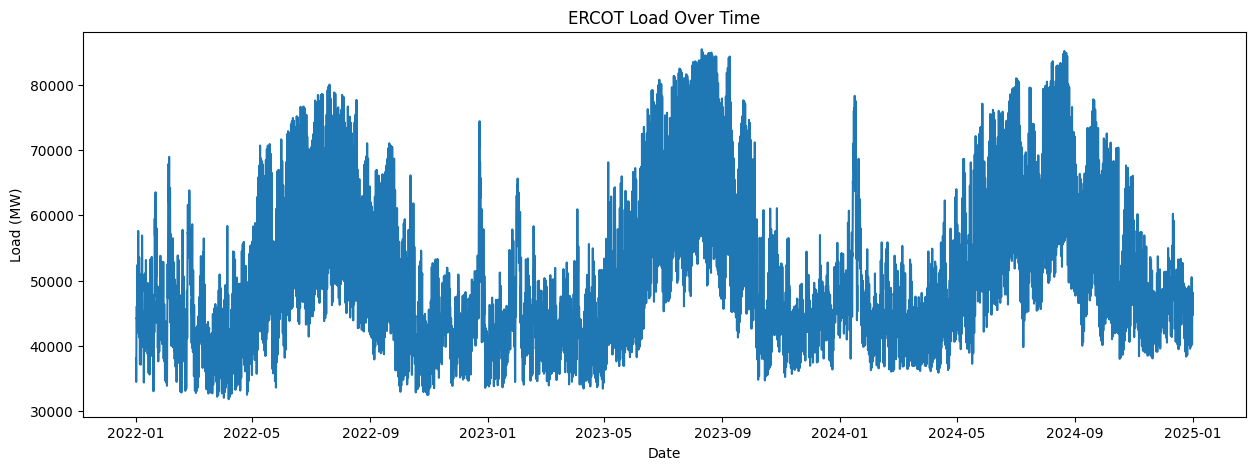

In [41]:
plt.figure(figsize=(15,5))
plt.plot(merged_df['datetime'], merged_df['load_mw'])
plt.title("ERCOT Load Over Time")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.show()

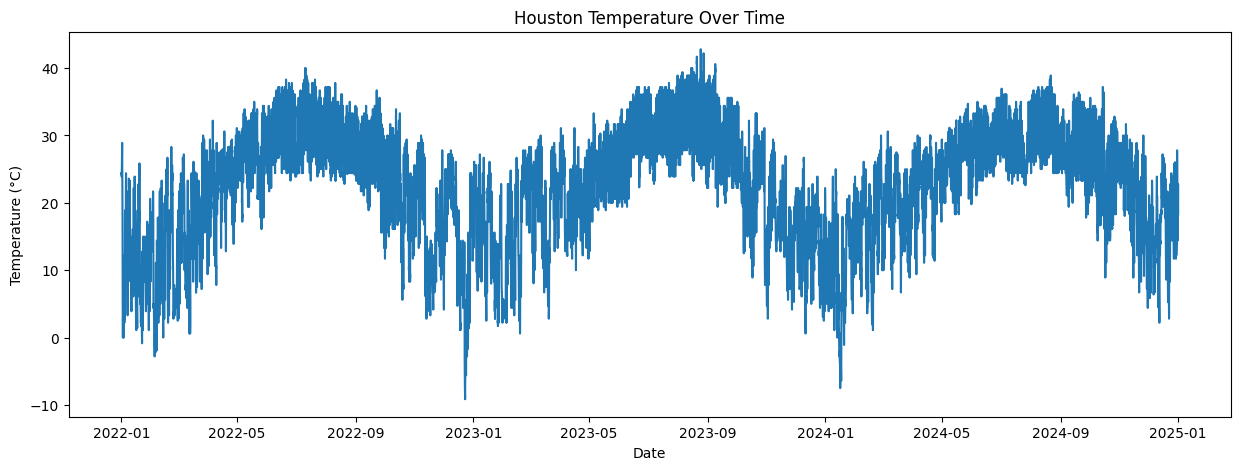

In [42]:
plt.figure(figsize=(15,5))
plt.plot(merged_df['datetime'], merged_df['TMP_C'])
plt.title("Houston Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

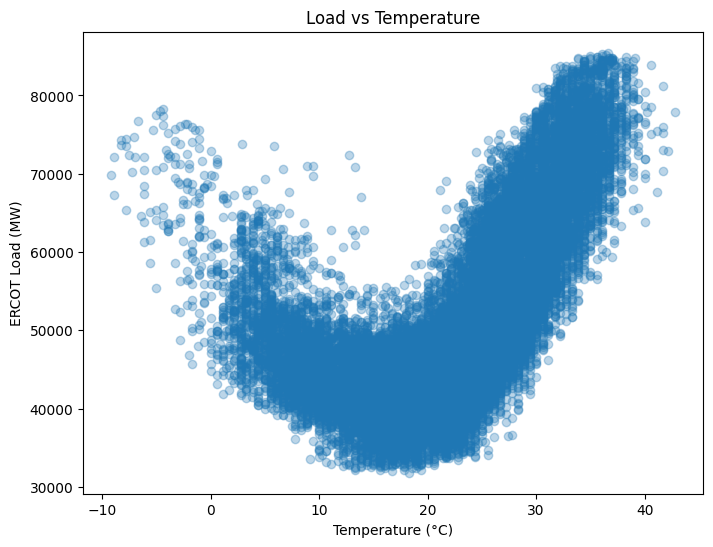

In [43]:
plt.figure(figsize=(8,6))
plt.scatter(merged_df['TMP_C'], merged_df['load_mw'], alpha=0.3)
plt.xlabel("Temperature (°C)")
plt.ylabel("ERCOT Load (MW)")
plt.title("Load vs Temperature")
plt.show()

In [39]:
print(merged_df[['TMP_C','load_mw']].corr())

            TMP_C   load_mw
TMP_C    1.000000  0.575246
load_mw  0.575246  1.000000


In [40]:
merged_df['TMP_C2'] = merged_df['TMP_C']**2

Regression Model

In [44]:
from sklearn.linear_model import LinearRegression

X = merged_df[['TMP_C','TMP_C2']]
y = merged_df['load_mw']

model = LinearRegression()
model.fit(X,y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("R²:", model.score(X,y))

Intercept: 58979.74037955418
Coefficients: [-2285.70498777    76.95245346]
R²: 0.683972731453153


Cell 13 - Temperature vs Load Curve

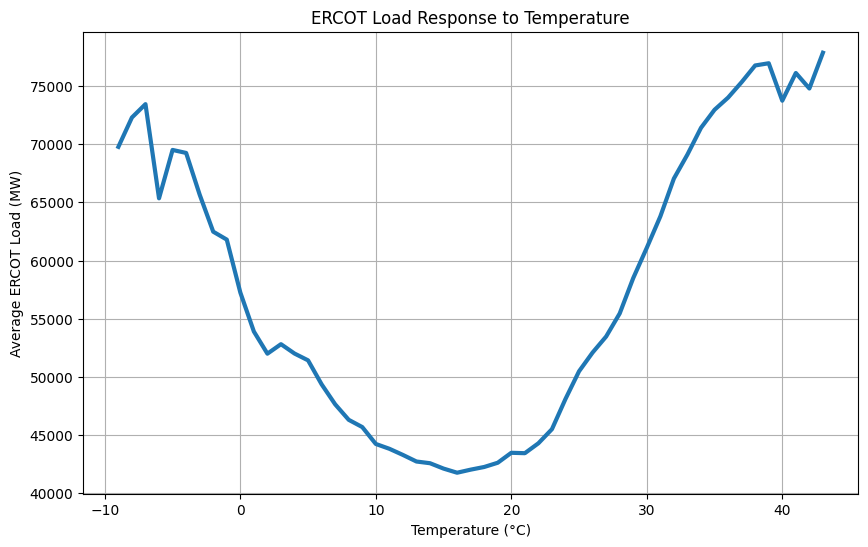

In [45]:
# Create temperature bins (rounded to nearest degree)
merged_df['temp_bin'] = merged_df['TMP_C'].round()

# Average load at each temperature
temp_curve = merged_df.groupby('temp_bin')['load_mw'].mean().reset_index()

plt.figure(figsize=(10,6))
plt.plot(temp_curve['temp_bin'], temp_curve['load_mw'], linewidth=3)

plt.xlabel("Temperature (°C)")
plt.ylabel("Average ERCOT Load (MW)")
plt.title("ERCOT Load Response to Temperature")

plt.grid(True)

plt.show()

Feature Engineering

In [46]:
merged_df['hour'] = merged_df['datetime'].dt.hour
merged_df['dayofweek'] = merged_df['datetime'].dt.dayofweek
merged_df['month'] = merged_df['datetime'].dt.month

Step 6 — Build a Simple Forecast Model

In [47]:
from sklearn.linear_model import LinearRegression

X = merged_df[['TMP_C','TMP_C2','hour','dayofweek','month']]
y = merged_df['load_mw']

model = LinearRegression()
model.fit(X,y)

print("Model R²:", model.score(X,y))

Model R²: 0.7115486229652399


Step 7 — Generate Forecast Values

In [48]:
merged_df['predicted_load'] = model.predict(X)

Step 8 — Model Performance Plot

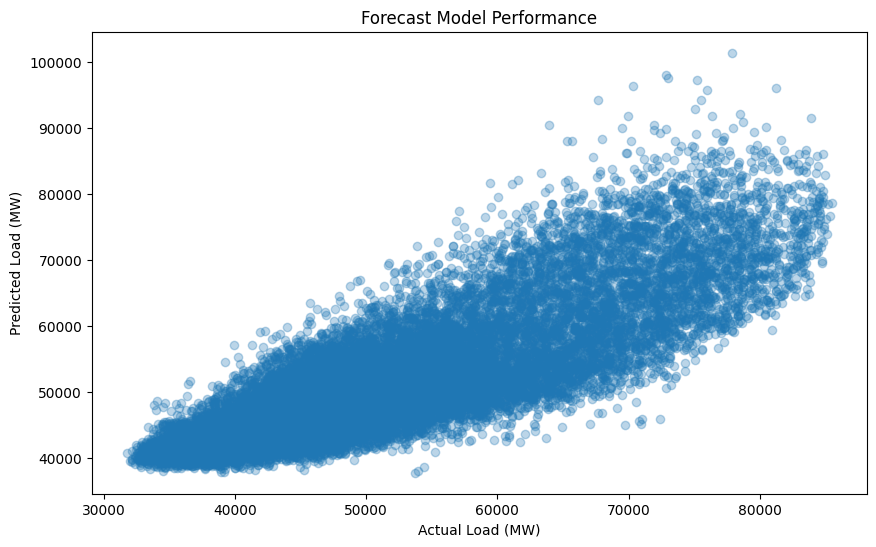

In [49]:
plt.figure(figsize=(10,6))
plt.scatter(merged_df['load_mw'], merged_df['predicted_load'], alpha=0.3)

plt.xlabel("Actual Load (MW)")
plt.ylabel("Predicted Load (MW)")
plt.title("Forecast Model Performance")

plt.show()